# Tutorial 05 — Attention: The Key Idea Behind Transformers

### From Machine Learning to Foundation Models · Hands-On AI for Power & Energy Systems

> **Can a model learn directly which observations matter to each other?**

---

## 1. Why this matters

The LSTM in tutorial 03 had to squeeze a week of history through one hidden
state, one hour at a time. Information about last Tuesday reaches the output
only by surviving 150 sequential updates — and we *measured* how little
survives. Worse, those 150 steps cannot be parallelised: step $t$ needs step
$t-1$.

Attention removes both problems at once. Every position can look at every
other position directly, in one matrix multiplication. That is why the
architecture scaled, and scaling is what made foundation models possible. If
you understand this notebook, tutorials 06 through 10 are variations on it.

We build it with NumPy first. No `nn.MultiheadAttention` until we have written
the equation ourselves and checked that PyTorch agrees.

## 2. Historical context

Attention was invented for machine translation, *inside* a recurrent network:
Bahdanau, Cho and Bengio (2014) let the decoder look back at all encoder
states instead of a single fixed vector. For three years it was a component
bolted onto RNNs. In 2017 Vaswani et al. removed the RNN and kept only the
attention — hence the title, *Attention Is All You Need*.

Worth keeping straight: attention is older than the Transformer, and the
Transformer is not the same thing as a language model. Tutorial 06 builds a
Transformer that never sees a word.

## 3. Learning objectives

By the end of this notebook you can:

- explain query, key and value, and what each one is *for*;
- derive and implement scaled dot-product attention in NumPy;
- explain why the $\sqrt{d_k}$ scaling exists and show what breaks without it;
- distinguish self-attention from cross-attention, and causal from
  bidirectional;
- explain why positional information must be added explicitly;
- implement multi-head attention and say what a second head buys;
- read an attention matrix over a power-system time series — and state clearly
  what it does *not* tell you.

In [1]:
from __future__ import annotations

import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

from ai_power_course import diagrams
from ai_power_course.config import fast_mode, scaled, set_seed
from ai_power_course.data import load_energy_data, time_split
from ai_power_course.models.attention import (
    MultiHeadSelfAttention,
    causal_mask,
    scaled_dot_product_attention_numpy,
    sinusoidal_positional_encoding,
    softmax_numpy,
)
from ai_power_course.models.training import TrainConfig, count_parameters, make_loader, train_model
from ai_power_course.plotting import COLORS, plot_attention, use_course_style

warnings.filterwarnings("ignore", category=FutureWarning)
use_course_style()
set_seed()
torch.set_num_threads(4)
print(f"reduced (CI) configuration: {fast_mode()}")

reduced (CI) configuration: False


## 4. Theory

### The lookup metaphor

A Python dictionary does a hard lookup: you give a key, you get one value.
Attention does a **soft, differentiable** version:

- the **query** $\mathbf{q}$ says *what am I looking for?*
- each **key** $\mathbf{k}_j$ says *what does position $j$ have to offer?*
- each **value** $\mathbf{v}_j$ says *what position $j$ returns if selected*

Instead of returning one value, return a weighted average of all of them,
weighted by how well each key matches the query:

$$\operatorname{Attention}(Q, K, V) = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Three steps: **score** (dot product), **normalise** (softmax), **aggregate**
(weighted sum). Everything is differentiable, so the model learns what to look
for rather than being told.

### Why $\sqrt{d_k}$

If the entries of $\mathbf{q}$ and $\mathbf{k}$ are independent with zero mean
and unit variance, their dot product $\sum_{i=1}^{d_k} q_i k_i$ has variance
$d_k$. At $d_k = 64$ the scores have a standard deviation of 8, the softmax
saturates, and its gradient vanishes. Dividing by $\sqrt{d_k}$ restores unit
variance. We will measure this in section 5.3.

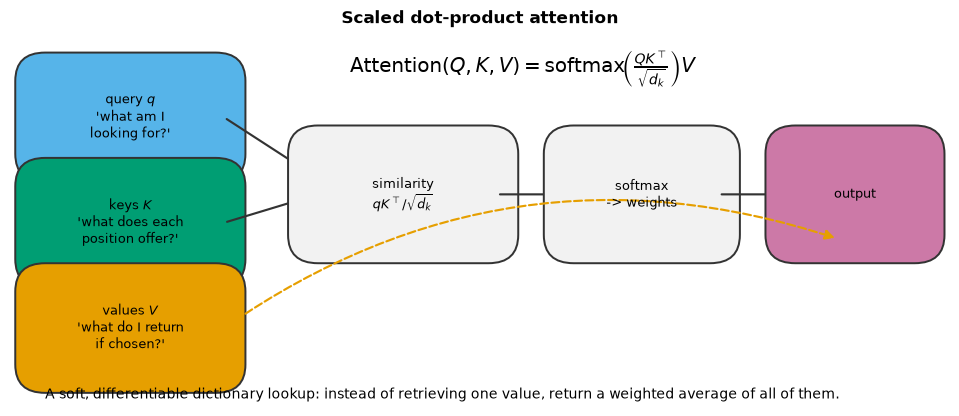

In [2]:
fig = diagrams.qkv_attention()
plt.show()

## 5. From scratch, in NumPy

### 5.1 One query, by hand

Four "positions" with deliberately transparent keys, so you can predict the
answer before running the cell.

In [3]:
keys = np.array([
    [1.0, 0.0],     # position 0: "morning-like"
    [0.0, 1.0],     # position 1: "evening-like"
    [1.0, 0.0],     # position 2: "morning-like" again
    [-1.0, 0.0],    # position 3: the opposite of morning
])
values = np.array([
    [10.0],         # what each position contributes if attended to
    [20.0],
    [12.0],
    [40.0],         # a distractor: a large value at an irrelevant position
])
query = np.array([[3.0, 0.0]])       # "I am looking for morning-like positions"

d_k = keys.shape[1]
scores = query @ keys.T / math.sqrt(d_k)
weights = softmax_numpy(scores)
output = weights @ values

breakdown = pd.DataFrame(
    {
        "key": [str(k) for k in keys],
        "value": values.ravel(),
        "score": scores.ravel().round(3),
        "weight": weights.ravel().round(3),
        "contribution": (weights.ravel() * values.ravel()).round(3),
    }
)
display(breakdown)
print(f"weights sum to {weights.sum():.3f}   ->   output = {output[0, 0]:.3f}")

,key,value,score,weight,contribution
0,[1. 0.],10.0,2.121,0.469,4.686
1,[0. 1.],20.0,0.000,0.056,1.123
2,[1. 0.],12.0,2.121,0.469,5.623
3,[-1. 0.],40.0,-2.121,0.007,0.269


weights sum to 1.000   ->   output = 11.701


Read the `contribution` column, not just the `weight` column — that is the
habit this example exists to build.

Positions 0 and 2 matched the query and take most of the weight, so the output
lands between their values of 10 and 12. Position 3 points the opposite way
and is nearly ignored despite carrying the largest value in the table.

But notice how easily that could have gone the other way. The output is a
weighted average of *values*, so a small weight on a large value still moves
the answer. A position with weight 0.01 and value 1000 contributes more than a
position with weight 0.5 and value 12. This is the first version of the
warning that section 7.2 makes properly: **an attention weight is not a
contribution**, and reading importance off the weights alone is a mistake.

In [4]:
print("What happens if the distractor's value grows, with the weights unchanged:")
for distractor in (40.0, 200.0, 1000.0):
    alternative = values.copy()
    alternative[3, 0] = distractor
    total = float((weights @ alternative).item())
    share = float(weights[0, 3] * distractor / total)
    print(f"  value at position 3 = {distractor:7.0f}  ->  output {total:8.2f}"
          f"   (position 3 supplies {share:5.1%} of it, at weight {weights[0, 3]:.3f})")

What happens if the distractor's value grows, with the weights unchanged:
  value at position 3 =      40  ->  output    11.70   (position 3 supplies  2.3% of it, at weight 0.007)
  value at position 3 =     200  ->  output    12.78   (position 3 supplies 10.5% of it, at weight 0.007)
  value at position 3 =    1000  ->  output    18.16   (position 3 supplies 37.1% of it, at weight 0.007)


### 5.2 The general implementation, checked against PyTorch

In [5]:
set_seed()
rng = np.random.default_rng(0)
SEQ, D_K, D_V = 6, 8, 4
Q = rng.normal(size=(SEQ, D_K))
K = rng.normal(size=(SEQ, D_K))
V = rng.normal(size=(SEQ, D_V))

ours, our_weights = scaled_dot_product_attention_numpy(Q, K, V)

torch_output = torch.nn.functional.scaled_dot_product_attention(
    torch.tensor(Q).unsqueeze(0), torch.tensor(K).unsqueeze(0), torch.tensor(V).unsqueeze(0)
).squeeze(0).numpy()

print(f"our output shape     : {ours.shape}")
print(f"max |difference| vs. torch.nn.functional : {np.abs(ours - torch_output).max():.2e}")
print(f"every row of the weight matrix sums to 1 : "
      f"{np.allclose(our_weights.sum(axis=1), 1.0)}")
assert np.allclose(ours, torch_output, atol=1e-10)
print("\nOur four lines of NumPy are the same function PyTorch ships.")

our output shape     : (6, 4)
max |difference| vs. torch.nn.functional : 2.22e-16
every row of the weight matrix sums to 1 : True

Our four lines of NumPy are the same function PyTorch ships.


### 5.3 What the scaling actually does

The claim from section 4, measured across key dimensions.

,score std (unscaled),score std (scaled),max softmax weight (unscaled),max softmax weight (scaled)
d_k,,,,
4,1.460,0.730,0.152,0.061
16,2.371,0.593,0.248,0.048
64,6.862,0.858,0.751,0.074
256,13.353,0.835,1.000,0.098
1024,28.019,0.876,0.998,0.054


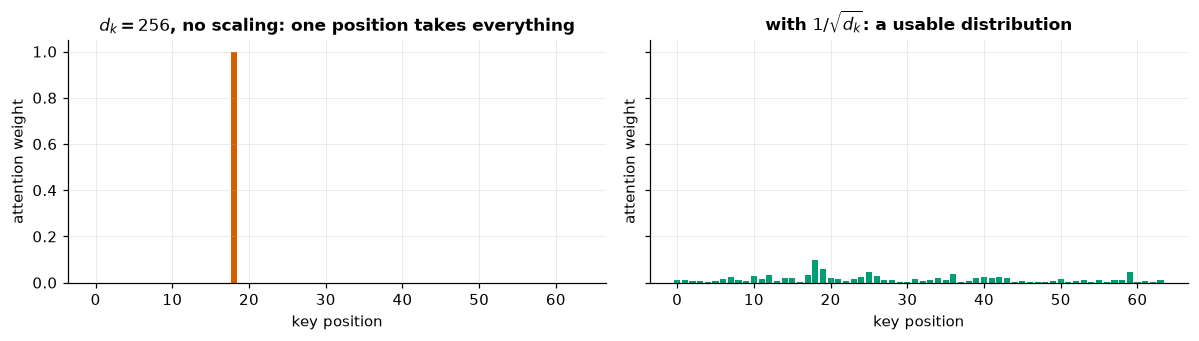

Without the scaling, attention at d_k = 256 is effectively an argmax: one weight
near 1, the rest near 0. A saturated softmax has a near-zero gradient, so the
model cannot learn to attend anywhere else. The division is not cosmetic — it is
what keeps the operation trainable as the model gets wider.


In [6]:
dimensions = [4, 16, 64, 256, 1024]
rows = []
for dimension in dimensions:
    rng = np.random.default_rng(1)
    q = rng.normal(size=(1, dimension))
    k = rng.normal(size=(64, dimension))
    unscaled = q @ k.T
    scaled_scores = unscaled / math.sqrt(dimension)
    rows.append(
        {
            "d_k": dimension,
            "score std (unscaled)": unscaled.std(),
            "score std (scaled)": scaled_scores.std(),
            "max softmax weight (unscaled)": softmax_numpy(unscaled).max(),
            "max softmax weight (scaled)": softmax_numpy(scaled_scores).max(),
        }
    )
scaling_table = pd.DataFrame(rows).set_index("d_k")
display(scaling_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
rng = np.random.default_rng(1)
q = rng.normal(size=(1, 256))
k = rng.normal(size=(64, 256))
axes[0].bar(range(64), softmax_numpy(q @ k.T)[0], color=COLORS["transformer"])
axes[0].set_title("$d_k=256$, no scaling: one position takes everything")
axes[1].bar(range(64), softmax_numpy(q @ k.T / math.sqrt(256))[0], color=COLORS["tree"])
axes[1].set_title(r"with $1/\sqrt{d_k}$: a usable distribution")
for ax in axes:
    ax.set_xlabel("key position")
    ax.set_ylabel("attention weight")
fig.tight_layout()
plt.show()

print("Without the scaling, attention at d_k = 256 is effectively an argmax: one weight")
print("near 1, the rest near 0. A saturated softmax has a near-zero gradient, so the")
print("model cannot learn to attend anywhere else. The division is not cosmetic — it is")
print("what keeps the operation trainable as the model gets wider.")

### 5.4 Self-attention, causal attention, cross-attention

The equation never changes. What changes is *where Q, K and V come from* and
*which positions are allowed to talk*.

| variant | Q from | K, V from | mask |
|---|---|---|---|
| **self-attention** | the sequence | the same sequence | none |
| **causal self-attention** | the sequence | the same sequence | lower triangular |
| **cross-attention** | sequence A | sequence B | task-dependent |

Causal masking is one line and it is the entire difference between a model
that fills in blanks (BERT) and a model that predicts the future (GPT).

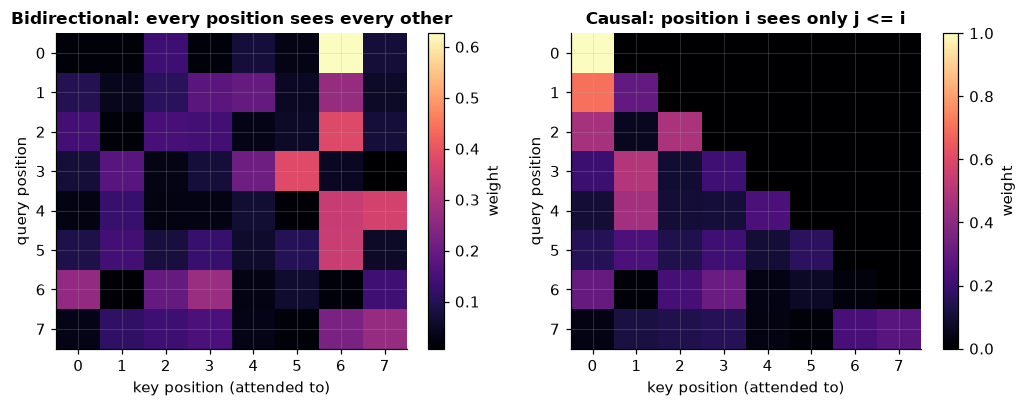

Causal weights above the diagonal: 0.0e+00
Exactly zero, because the mask sets those scores to -inf *before* the softmax.
Masking after the softmax would leave the remaining weights not summing to 1.


In [7]:
mask = causal_mask(8).numpy()
rng = np.random.default_rng(3)
Q8 = rng.normal(size=(8, 16))
K8 = rng.normal(size=(8, 16))
V8 = rng.normal(size=(8, 16))

_, weights_open = scaled_dot_product_attention_numpy(Q8, K8, V8)
_, weights_causal = scaled_dot_product_attention_numpy(Q8, K8, V8, mask=mask)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
plot_attention(weights_open, title="Bidirectional: every position sees every other",
               tick_step=1, ax=axes[0])
plot_attention(weights_causal, title="Causal: position i sees only j <= i",
               tick_step=1, ax=axes[1])
fig.tight_layout()
plt.show()

print(f"Causal weights above the diagonal: {weights_causal[np.triu_indices(8, k=1)].max():.1e}")
print("Exactly zero, because the mask sets those scores to -inf *before* the softmax.")
print("Masking after the softmax would leave the remaining weights not summing to 1.")

### 5.5 Attention has no idea what order things are in

A property that surprises people, and which we can demonstrate in four lines:
permute the input and the outputs permute with it. Attention is
*permutation-equivariant*. For a bag of words that might be tolerable. For a
load time series it is fatal.

In [8]:
set_seed()
rng = np.random.default_rng(5)
X = rng.normal(size=(6, 8))
out_original, _ = scaled_dot_product_attention_numpy(X, X, X)

permutation = np.array([3, 1, 5, 0, 4, 2])
out_permuted, _ = scaled_dot_product_attention_numpy(X[permutation], X[permutation], X[permutation])

print(f"max |attention(shuffled) - shuffle(attention(original))| = "
      f"{np.abs(out_permuted - out_original[permutation]).max():.2e}")
print("\nIdentical. The operation genuinely cannot tell 09:00 from 21:00.")
print("Position has to be *added to the representation*, which is what positional")
print("encoding does.")

max |attention(shuffled) - shuffle(attention(original))| = 2.22e-16

Identical. The operation genuinely cannot tell 09:00 from 21:00.
Position has to be *added to the representation*, which is what positional
encoding does.


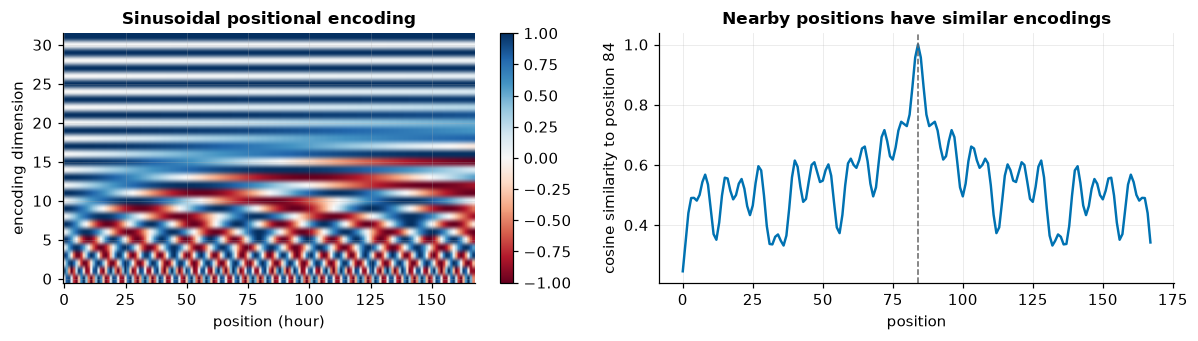

Geometrically spaced frequencies mean a fixed offset (say, +24 hours) corresponds
to a fixed rotation, so the model can express 'one day earlier' as a linear
operation. Modern models mostly use learned or rotary (RoPE) encodings instead,
but the requirement is the same: attention needs to be told about order.


In [9]:
encoding = sinusoidal_positional_encoding(length=168, d_model=32).numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
image = axes[0].imshow(encoding.T, aspect="auto", cmap="RdBu", origin="lower")
plt.colorbar(image, ax=axes[0])
axes[0].set_xlabel("position (hour)")
axes[0].set_ylabel("encoding dimension")
axes[0].set_title("Sinusoidal positional encoding")

similarity = encoding @ encoding.T
similarity /= np.linalg.norm(encoding, axis=1, keepdims=True) * np.linalg.norm(encoding, axis=1)
axes[1].plot(similarity[84], color=COLORS["rnn"])
axes[1].axvline(84, ls="--", color="#666", lw=1)
axes[1].set_xlabel("position")
axes[1].set_ylabel("cosine similarity to position 84")
axes[1].set_title("Nearby positions have similar encodings")
fig.tight_layout()
plt.show()

print("Geometrically spaced frequencies mean a fixed offset (say, +24 hours) corresponds")
print("to a fixed rotation, so the model can express 'one day earlier' as a linear")
print("operation. Modern models mostly use learned or rotary (RoPE) encodings instead,")
print("but the requirement is the same: attention needs to be told about order.")

## 6. Multi-head attention

One softmax produces one weighted average — one "opinion" about what is
relevant. A load forecaster plausibly wants to look at *the last few hours*
and *the same hour yesterday* at the same time. With one head it must choose;
with several it does not have to.

In [10]:
set_seed()
attention_module = MultiHeadSelfAttention(d_model=32, n_heads=4)
sample = torch.randn(2, 12, 32)
output, head_weights = attention_module(sample, need_weights=True)

print(f"input          {tuple(sample.shape)}   (batch, positions, d_model)")
print(f"output         {tuple(output.shape)}")
print(f"head weights   {tuple(head_weights.shape)}   (batch, heads, query, key)")
print(f"parameters     {count_parameters(attention_module):,}")
print(f"\nd_model = 32 split into 4 heads of {32 // 4} dimensions each — the total width is")
print("unchanged, so multi-head attention is essentially free.")

# Cross-check our implementation against PyTorch's optimised one.
torch_attention = nn.MultiheadAttention(embed_dim=32, num_heads=4, batch_first=True, bias=True)
with torch.no_grad():
    torch_attention.in_proj_weight.copy_(torch.cat([
        attention_module.query_proj.weight,
        attention_module.key_proj.weight,
        attention_module.value_proj.weight,
    ]))
    torch_attention.in_proj_bias.copy_(torch.cat([
        attention_module.query_proj.bias,
        attention_module.key_proj.bias,
        attention_module.value_proj.bias,
    ]))
    torch_attention.out_proj.weight.copy_(attention_module.out_proj.weight)
    torch_attention.out_proj.bias.copy_(attention_module.out_proj.bias)
    reference_output, _ = torch_attention(sample, sample, sample, need_weights=False)

print(f"\nmax |ours - nn.MultiheadAttention| = "
      f"{(output - reference_output).abs().max().item():.2e}")

input          (2, 12, 32)   (batch, positions, d_model)
output         (2, 12, 32)
head weights   (2, 4, 12, 12)   (batch, heads, query, key)
parameters     4,224

d_model = 32 split into 4 heads of 8 dimensions each — the total width is
unchanged, so multi-head attention is essentially free.

max |ours - nn.MultiheadAttention| = 8.94e-08


## 7. Power-system application: what does the model look at?

We train a **single attention layer** on load sequences — deliberately the
smallest thing that can show learned attention patterns — and then read its
weights.

In [11]:
frame = load_energy_data().frame
train_raw, valid_raw, test_raw = time_split(frame)

CONTEXT = 72        # three days, short enough that the attention matrix is readable
HORIZON = 24


def sequences(part: pd.DataFrame, history: pd.DataFrame | None = None):
    series = part.load_mw
    if history is not None:
        series = pd.concat([history.load_mw.tail(CONTEXT), series])
    values = series.to_numpy(dtype=np.float32)
    starts = np.arange(len(values) - CONTEXT - HORIZON + 1)
    x = np.stack([values[s : s + CONTEXT] for s in starts])
    y = np.stack([values[s + CONTEXT + HORIZON - 1] for s in starts])
    stamps = series.index[CONTEXT + HORIZON - 1 :][: len(starts)]
    return x[:, :, None], y[:, None], stamps


x_train, y_train, _ = sequences(train_raw)
x_valid, y_valid, _ = sequences(valid_raw, history=train_raw)
x_test, y_test, stamps_test = sequences(test_raw, history=valid_raw)

mean, std = x_train.mean(), x_train.std()
xs_train, xs_valid, xs_test = ((a - mean) / std for a in (x_train, x_valid, x_test))
ys_train, ys_valid = ((a - mean) / std for a in (y_train, y_valid))

print(f"x_train {x_train.shape}  y_train {y_train.shape}")


class SingleAttentionForecaster(nn.Module):
    """Embed -> add position -> ONE self-attention layer -> read the last position.

    Nothing else: no feed-forward block, no residual stack, no second layer.
    The point is to see what a single attention operation learns to look at.
    """

    def __init__(self, context: int, d_model: int = 32, n_heads: int = 4) -> None:
        super().__init__()
        self.embed = nn.Linear(1, d_model)
        self.register_buffer("positional", sinusoidal_positional_encoding(context, d_model))
        self.attention = MultiHeadSelfAttention(d_model, n_heads)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor, need_weights: bool = False):
        h = self.embed(x) + self.positional.unsqueeze(0)
        attended, weights = self.attention(self.norm(h), need_weights=need_weights)
        prediction = self.head((h + attended)[:, -1, :])
        return (prediction, weights) if need_weights else prediction


set_seed()
model = SingleAttentionForecaster(CONTEXT)
history = train_model(
    model,
    make_loader(xs_train, ys_train, batch_size=64, shuffle=True),
    make_loader(xs_valid, ys_valid, batch_size=256),
    loss_fn=nn.MSELoss(),
    config=TrainConfig(epochs=scaled(full=25, fast=2), learning_rate=2e-3, patience=6,
                       verbose=False),
)
print(f"{count_parameters(model):,} parameters, best epoch {history.best_epoch}, "
      f"validation MSE {history.best_val_loss:.4f}")

x_train (17425, 72, 1)  y_train (17425, 1)


4,385 parameters, best epoch 4, validation MSE 0.2525


### 7.1 Reading the attention matrix

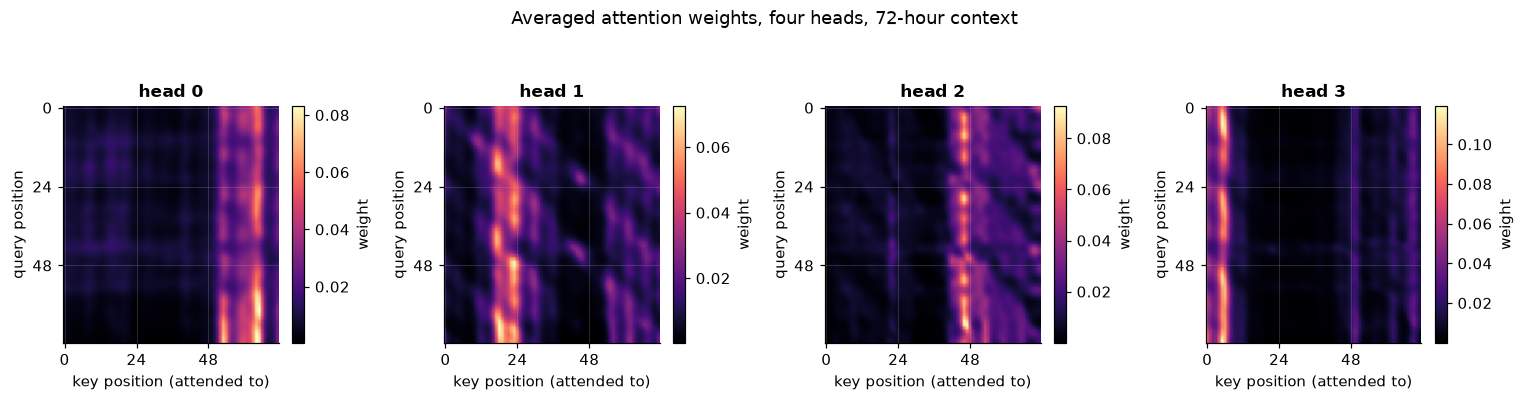

In [12]:
model.eval()
with torch.no_grad():
    batch = torch.tensor(xs_test[:256], dtype=torch.float32)
    _, weights = model(batch, need_weights=True)
attention = weights.mean(dim=0).numpy()          # average over the batch -> (heads, q, k)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for head in range(attention.shape[0]):
    plot_attention(attention[head], title=f"head {head}", tick_step=24, ax=axes[head])
fig.suptitle("Averaged attention weights, four heads, 72-hour context", y=1.06)
fig.tight_layout()
plt.show()

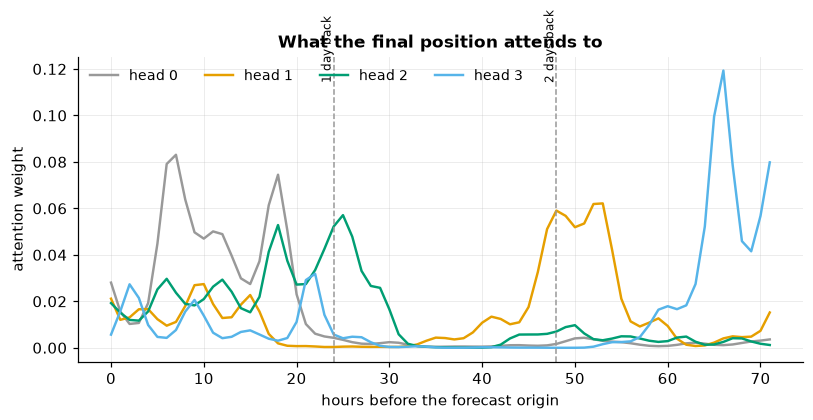

,weight on last 6 h,weight on 24 +/- 2 h,weight on 48 +/- 2 h,entropy of the row,max possible entropy
head 0,0.129,0.029,0.007,3.332,4.277
head 1,0.092,0.002,0.217,3.693,4.277
head 2,0.099,0.213,0.033,3.745,4.277
head 3,0.085,0.085,0.000,3.315,4.277


The entropy column is the useful diagnostic. A row close to log(72) = 4.28 is a
near-uniform average — that head is not selecting anything. A much lower value
means the head has concentrated on a few positions.


In [13]:
# The row that matters: the final position is the one the forecast is read from.
last_row = attention[:, -1, :]
lags = np.arange(CONTEXT)[::-1]                 # 71 = oldest, 0 = most recent

fig, ax = plt.subplots(figsize=(8.5, 3.6))
for head in range(last_row.shape[0]):
    ax.plot(lags, last_row[head], label=f"head {head}")
for marker, label in [(24, "1 day back"), (48, "2 days back")]:
    ax.axvline(marker, ls="--", color="#999", lw=1)
    ax.text(marker, ax.get_ylim()[1] * 0.92, label, rotation=90, fontsize=8, ha="right")
ax.set_xlabel("hours before the forecast origin")
ax.set_ylabel("attention weight")
ax.set_title("What the final position attends to")
ax.legend(ncol=4)
plt.show()

summary = pd.DataFrame(
    {
        "weight on last 6 h": last_row[:, -6:].sum(axis=1),
        "weight on 24 +/- 2 h": last_row[:, CONTEXT - 26 : CONTEXT - 21].sum(axis=1),
        "weight on 48 +/- 2 h": last_row[:, CONTEXT - 50 : CONTEXT - 45].sum(axis=1),
        "entropy of the row": [-np.sum(w * np.log(w + 1e-12)) for w in last_row],
    },
    index=[f"head {i}" for i in range(last_row.shape[0])],
)
summary["max possible entropy"] = np.log(CONTEXT)
display(summary.round(3))

print("The entropy column is the useful diagnostic. A row close to log(72) = 4.28 is a")
print("near-uniform average — that head is not selecting anything. A much lower value")
print("means the head has concentrated on a few positions.")

### 7.2 Attention is not an explanation

This deserves its own section, because reading causal claims off attention
maps is one of the most common mistakes in applied deep learning.

Three reasons an attention weight is not "the reason the model decided":

1. **The value vector matters too.** A large weight on a position whose value
   vector is near zero contributes nothing.
2. **Residual connections route around attention.** In a real Transformer the
   representation flows through the residual stream whether attention looks at
   it or not.
3. **Different attention patterns can produce identical outputs.** Jain and
   Wallace (2019) constructed adversarial weight distributions that leave
   predictions unchanged.

We can test the third point directly: shuffle the attention weights and see
how much the prediction actually changes.

In [14]:
from ai_power_course.metrics import mae  # noqa: E402  (imported here to make the point local)

with torch.no_grad():
    baseline_prediction = model(torch.tensor(xs_test, dtype=torch.float32)).numpy().ravel()
    baseline_mw = baseline_prediction * std + mean

# Replace attention with a uniform average — no selection at all.
class UniformAttention(nn.Module):
    def __init__(self, original: MultiHeadSelfAttention) -> None:
        super().__init__()
        self.original = original

    def forward(self, x, mask=None, need_weights=False):
        values = self.original.value_proj(x)
        uniform = values.mean(dim=1, keepdim=True).expand_as(values)
        return self.original.out_proj(uniform), None


original_attention = model.attention
model.attention = UniformAttention(original_attention)
with torch.no_grad():
    uniform_prediction = model(torch.tensor(xs_test, dtype=torch.float32)).numpy().ravel()
uniform_mw = uniform_prediction * std + mean
model.attention = original_attention

truth = y_test.ravel()
print(f"learned attention   MAE {mae(truth, baseline_mw):8,.1f} MW")
print(f"uniform attention   MAE {mae(truth, uniform_mw):8,.1f} MW")
print(f"agreement between the two predictions: r = "
      f"{np.corrcoef(baseline_mw, uniform_mw)[0, 1]:.3f}")
print(f"mean |difference|  : {np.abs(baseline_mw - uniform_mw).mean():,.1f} MW")
print("\nHow much the learned pattern matters is an empirical question with a number")
print("attached, not something to be inferred from how convincing the heatmap looks.")
print("Report the ablation, not the picture.")

learned attention   MAE  2,565.1 MW
uniform attention   MAE  3,745.4 MW
agreement between the two predictions: r = 0.901
mean |difference|  : 2,436.9 MW

How much the learned pattern matters is an empirical question with a number
attached, not something to be inferred from how convincing the heatmap looks.
Report the ablation, not the picture.


## 8. Cost: the price of looking everywhere

Attention compares every position with every other position. That is
$O(n^2)$ in time and memory, against $O(n)$ for a recurrence. The trade is
**depth for width**: an RNN needs $n$ sequential steps, attention needs one
step over an $n \times n$ matrix — slower in theory, vastly faster in practice
because it parallelises.

In [15]:
lengths = [24, 168, 720, 8760]
cost = pd.DataFrame(
    {
        "sequence length": lengths,
        "attention matrix entries": [n * n for n in lengths],
        "memory at fp32 [MB]": [n * n * 4 / 1e6 for n in lengths],
        "sequential steps (RNN)": lengths,
        "sequential steps (attention)": [1] * len(lengths),
    }
).set_index("sequence length")
display(cost.round(2))

print("One year of hourly data is 8,760 steps: 77 million attention entries, 307 MB per")
print("head per layer per example. This quadratic wall is why long-context work exists —")
print("sparse and local attention, FlashAttention's memory-efficient kernels, and")
print("state-space models such as Mamba (Gu & Dao, 2023), which are linear in length.")
print("Tutorial 06 returns to this.")

,attention matrix entries,memory at fp32 [MB],sequential steps (RNN),sequential steps (attention)
sequence length,,,,
24,576,0.00,24,1
168,28224,0.11,168,1
720,518400,2.07,720,1
8760,76737600,306.95,8760,1


One year of hourly data is 8,760 steps: 77 million attention entries, 307 MB per
head per layer per example. This quadratic wall is why long-context work exists —
sparse and local attention, FlashAttention's memory-efficient kernels, and
state-space models such as Mamba (Gu & Dao, 2023), which are linear in length.
Tutorial 06 returns to this.


## 9. Failure analysis

When does a single attention layer do badly?

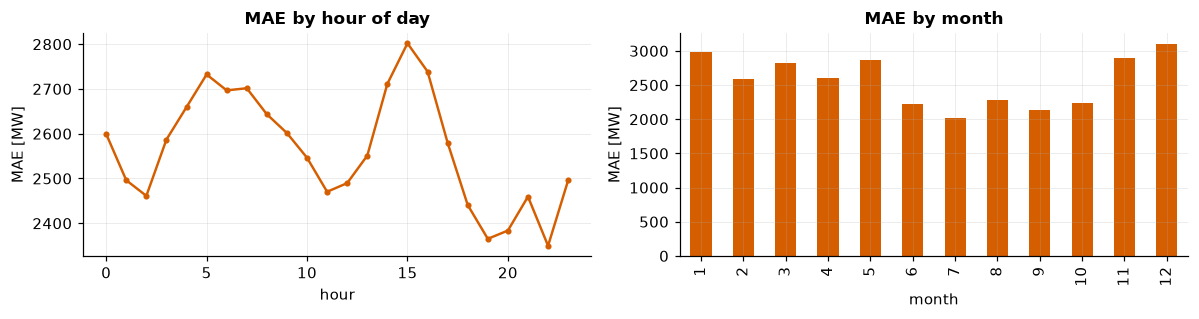

Overall MAE 2,565 MW from a single attention layer with
4,385 parameters and no feed-forward block at all.

For reference, the LSTM in tutorial 03 reached about 1,640 MW — but it had a
168-hour context and five extra input channels, so this is not a fair fight and
is not meant to be. Tutorial 06 builds the missing pieces and does compare.


In [16]:
errors = pd.DataFrame(
    {
        "absolute_error": np.abs(baseline_mw - truth),
        "hour": stamps_test.hour,
        "month": stamps_test.month,
        "observed": truth,
    },
    index=stamps_test,
)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
errors.groupby("hour").absolute_error.mean().plot(ax=axes[0], marker="o", ms=3,
                                                  color=COLORS["transformer"],
                                                  title="MAE by hour of day")
errors.groupby("month").absolute_error.mean().plot(kind="bar", ax=axes[1],
                                                   color=COLORS["transformer"],
                                                   title="MAE by month")
for ax in axes:
    ax.set_ylabel("MAE [MW]")
fig.tight_layout()
plt.show()

print(f"Overall MAE {mae(truth, baseline_mw):,.0f} MW from a single attention layer with")
print(f"{count_parameters(model):,} parameters and no feed-forward block at all.")
print("\nFor reference, the LSTM in tutorial 03 reached about 1,640 MW — but it had a")
print("168-hour context and five extra input channels, so this is not a fair fight and")
print("is not meant to be. Tutorial 06 builds the missing pieces and does compare.")

## 10. Exercises

**1 — Conceptual.** Section 5.5 showed that attention is permutation-
equivariant and that positional encoding repairs it. Now think about a
*graph* instead of a sequence: in tutorial 10 we attend over the buses of an
electrical network, where there is no natural ordering and permutation
equivariance is exactly what we *want*. What would a "positional encoding"
even mean for a power-system bus, and which properties would it need to be
useful? (There is no single right answer; the GridFM literature is actively
arguing about it.)

**2 — Coding.** Plot the attention matrix and determine whether the learned
dependency really corresponds to daily periodicity. Concretely: take the final
row of each head, compute its autocorrelation, and test whether there is a
peak at a 24-hour offset. Then retrain with the positional encoding removed
and repeat. Does the periodic structure survive, and what does that tell you
about where the model gets its notion of "yesterday"?

**3 — Research.** Section 7.2 replaced the learned attention with a uniform
average and measured the damage. Extend this into a proper ablation study: (a)
uniform weights, (b) reversed weights, (c) weights from a *different*
randomly-initialised model, (d) weights permuted within each row. Report MAE
for each. Then read Jain & Wallace, "Attention is not Explanation" (NAACL
2019) and Wiegreffe & Pinter, "Attention is not not Explanation" (EMNLP 2019),
and write a paragraph on which of your four ablations each paper would accept
as evidence.

## 11. Key takeaways

- **Attention is a soft dictionary lookup**: score with a dot product,
  normalise with a softmax, aggregate as a weighted sum. Four lines of NumPy,
  bit-identical to PyTorch's.
- **The $\sqrt{d_k}$ scaling keeps the softmax out of saturation.** We
  measured a near-argmax distribution without it at $d_k = 256$.
- **A causal mask is one line** and is the whole difference between an
  encoder that fills in blanks and a decoder that predicts the future.
- **Attention has no notion of order.** Position must be added explicitly —
  and in a graph setting, that permutation equivariance becomes a feature.
- **An attention map is not an explanation.** Ablate the weights and report
  the number; do not narrate the heatmap.
- **The cost is quadratic in sequence length**, which is the constraint every
  long-context method since 2020 has been trying to get around.

## 12. Further reading

- Vaswani et al., "Attention Is All You Need",
  [arXiv:1706.03762](https://arxiv.org/abs/1706.03762).
- Bahdanau, Cho & Bengio, "Neural Machine Translation by Jointly Learning to
  Align and Translate", [arXiv:1409.0473](https://arxiv.org/abs/1409.0473) —
  attention before the Transformer.
- Jain & Wallace, "Attention is not Explanation", NAACL 2019.
  [arXiv:1902.10186](https://arxiv.org/abs/1902.10186)
- Wiegreffe & Pinter, "Attention is not not Explanation", EMNLP 2019.
  [arXiv:1908.04626](https://arxiv.org/abs/1908.04626)
- Alammar, "The Illustrated Transformer".
  <https://jalammar.github.io/illustrated-transformer/>

---

**Next:** [Tutorial 06 — Build a Transformer from Scratch](06_transformers.ipynb).
We assemble attention, residual connections, layer normalisation and a
feed-forward block into the architecture that everything else in this course
is built on.